# UPI Guardian - explaining one payment
How M3 (the score users see) decides, using SHAP on a high-risk payment from the simulator sample.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "backend")); sys.path.insert(0, str(ROOT / "ml"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
RAW = ROOT / "data" / "raw"
print("project root:", ROOT)
import joblib, shap
bundle = joblib.load(ROOT/"models"/"risk_model.joblib")
from app.ml.features import RISK_FEATURES
from app.services.risk import score_from_probability
sim = pd.read_csv(ROOT/"data"/"sample"/"upi_scenarios_sample.csv")
X = sim[RISK_FEATURES]
sim["probability"] = bundle["model"].predict_proba(X)[:, 1]
sim["score"] = [score_from_probability(p, bundle["score_anchors"]) for p in sim.probability]
sim.groupby("label").score.describe().round(1)

project root: D:\abstracts\Madhav\CSDS\B\CSDS-B-B4\8.ProjectCode


D:\abstracts\Madhav\CSDS\B\CSDS-B-B4\8.ProjectCode\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4000.0,2.4,7.6,0.0,0.0,0.0,1.0,84.0
1,1000.0,88.6,22.8,0.0,88.0,99.0,100.0,100.0


scam type: impersonation | score: 97 | amount: 22802.0


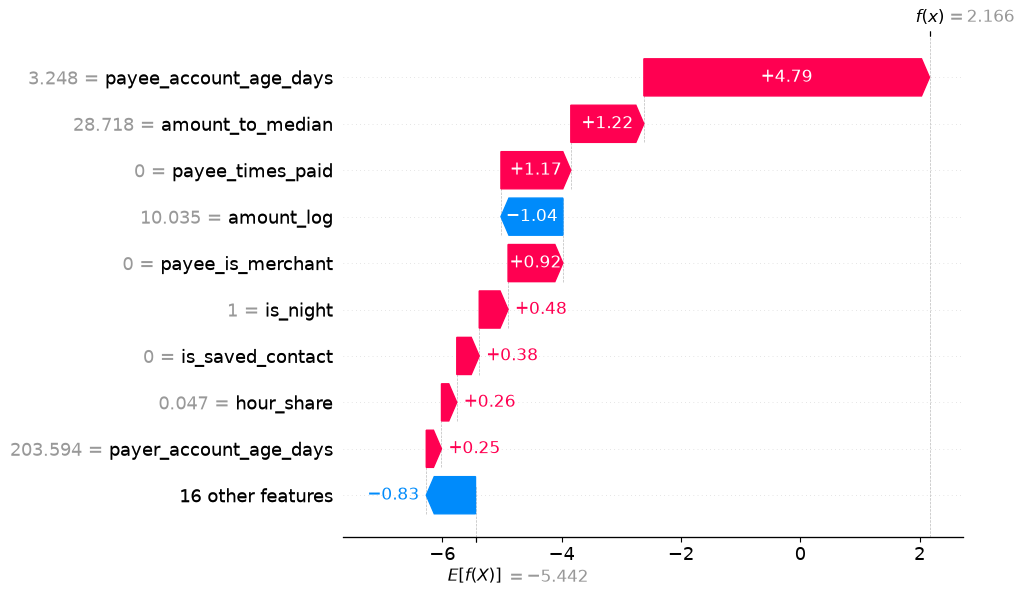

In [2]:
row = sim[(sim.label == 1) & (sim.scam_type == "impersonation")].sort_values("score").iloc[len(sim[(sim.label==1)&(sim.scam_type=="impersonation")])//2]
print("scam type:", row.scam_type, "| score:", row.score, "| amount:", row.amount)
explainer = shap.TreeExplainer(bundle["model"])
exp = explainer(X.loc[[row.name]])
shap.plots.waterfall(exp[0], max_display=10, show=True)

In [3]:
from app.services.explain import build_reasons
contrib = dict(zip(RISK_FEATURES, exp.values[0]))
feats = {k: float(row[k]) for k in RISK_FEATURES}
risk, safe = build_reasons(feats, contrib, {"payee_name": "this receiver", "amount": float(row.amount), "local_time": "late night",
                                            "has_history": True, "report_count": int(row.payee_reports > 0), "m1_top": None})
for r in risk: print("RISK  ", r["text"]["en"], "|", r["text"]["hi"])
for r in safe: print("SAFE  ", r["text"]["en"])

RISK   this receiver's account is only 3 days old. | this receiver का खाता सिर्फ़ 3 दिन पुराना है।
RISK   This is 29 times more than you usually pay. | यह आपके आम भुगतान से 29 गुना ज़्यादा है।
RISK   It is late night - late-night payments are common in scams. | अभी late night बजे हैं - देर रात के भुगतान अक्सर धोखाधड़ी में होते हैं।
RISK   You rarely pay at this time of day. | आप इस समय बहुत कम भुगतान करते हैं।
